In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = "/content/drive/MyDrive/taxigps.csv"

df = pd.read_csv(file_path)

In [4]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.3 MB/s eta 0:00:00


In [5]:
# import liabilities
import pandas as pd
import numpy as np

import networkx as nx

import torch
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

import matplotlib.pyplot as plt

In [6]:
# Read Dataset
df = pd.read_csv(
"/content/drive/MyDrive/taxigps.csv"
)

print(df.head())

    Taxi_ID            Timestamp   Latitude  Longitude Road_ID  Speed_kmh  \
0  TX017274  2025-01-01 00:00:00  40.738698 -73.985059  R03889         30   
1  TX001466  2025-01-01 00:00:30  40.721944 -73.996924  R04459         67   
2  TX015015  2025-01-01 00:01:00  40.742930 -74.019236  R03284         42   
3  TX000933  2025-01-01 00:01:30  40.734868 -74.003199  R02474         79   
4  TX015270  2025-01-01 00:02:00  40.704709 -73.990651  R00437         21   

  Traffic_Level  Distance_km  Travel_Time_min  
0        Medium         2.41             5.17  
1           Low         4.03             4.27  
2           Low         4.82             7.57  
3           Low         1.43             3.55  
4        Medium         6.52            19.43  


In [7]:
# Dataset Check
print(df.shape)

print(df.columns)

print(df.info())

(1000000, 9)
Index(['Taxi_ID', 'Timestamp', 'Latitude', 'Longitude', 'Road_ID', 'Speed_kmh',
       'Traffic_Level', 'Distance_km', 'Travel_Time_min'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Taxi_ID          1000000 non-null  object 
 1   Timestamp        1000000 non-null  object 
 2   Latitude         1000000 non-null  float64
 3   Longitude        1000000 non-null  float64
 4   Road_ID          1000000 non-null  object 
 5   Speed_kmh        1000000 non-null  int64  
 6   Traffic_Level    1000000 non-null  object 
 7   Distance_km      1000000 non-null  float64
 8   Travel_Time_min  1000000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 68.7+ MB
None


In [8]:
# Missing Values
print(df.isnull().sum())

Taxi_ID            0
Timestamp          0
Latitude           0
Longitude          0
Road_ID            0
Speed_kmh          0
Traffic_Level      0
Distance_km        0
Travel_Time_min    0
dtype: int64


In [9]:
# Remove Missing Values
df = df.dropna()

In [10]:
# Remove Duplicates
df = df.drop_duplicates()

In [11]:
# Convert Timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [12]:
# Feature Engineering
df["Hour"] = df["Timestamp"].dt.hour

df["Day"] = df["Timestamp"].dt.day

df["Month"] = df["Timestamp"].dt.month

In [13]:
# Encode Traffic Level
encoder = LabelEncoder()

df["Traffic_Level"] = encoder.fit_transform(
    df["Traffic_Level"]
)

In [14]:
# Check Dataset
print(df.head())

    Taxi_ID           Timestamp   Latitude  Longitude Road_ID  Speed_kmh  \
0  TX017274 2025-01-01 00:00:00  40.738698 -73.985059  R03889         30   
1  TX001466 2025-01-01 00:00:30  40.721944 -73.996924  R04459         67   
2  TX015015 2025-01-01 00:01:00  40.742930 -74.019236  R03284         42   
3  TX000933 2025-01-01 00:01:30  40.734868 -74.003199  R02474         79   
4  TX015270 2025-01-01 00:02:00  40.704709 -73.990651  R00437         21   

   Traffic_Level  Distance_km  Travel_Time_min  Hour  Day  Month  
0              2         2.41             5.17     0    1      1  
1              1         4.03             4.27     0    1      1  
2              1         4.82             7.57     0    1      1  
3              1         1.43             3.55     0    1      1  
4              2         6.52            19.43     0    1      1  


In [15]:
# Create Graph
import networkx as nx

G = nx.Graph()

In [17]:
# Build Road Network
for road_id, group in df.groupby("Road_ID"):

    group = group.sort_values("Timestamp").reset_index(drop=True)

    coords = [
        (round(lat, 6), round(lon, 6))
        for lat, lon in zip(group["Latitude"], group["Longitude"])
    ]

    for i in range(len(group)):

        node = coords[i]

        if node not in G:

            G.add_node(
                node,
                speed=float(group.loc[i, "Speed_kmh"]),
                distance=float(group.loc[i, "Distance_km"]),
                hour=int(group.loc[i, "Hour"]),
                day=int(group.loc[i, "Day"]),
                month=int(group.loc[i, "Month"]),
                traffic=int(group.loc[i, "Traffic_Level"])
            )

    for i in range(len(coords) - 1):

        G.add_edge(
            coords[i],
            coords[i + 1],
            weight=float(group.loc[i, "Travel_Time_min"])
        )
print("Number of Nodes :", G.number_of_nodes())
print("Number of Edges :", G.number_of_edges())

Number of Nodes : 999800
Number of Edges : 995000


In [18]:
# Check Graph
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())
print("Connected Components :", nx.number_connected_components(G))

Nodes : 999800
Edges : 995000
Connected Components : 4800


In [19]:
# Create Node Mapping
node_to_index = {
    node: i
    for i, node in enumerate(G.nodes())
}

In [20]:
# Create Node Features
node_features = []
labels = []

for node in G.nodes():

    attr = G.nodes[node]

    node_features.append([
        attr["speed"],
        attr["distance"],
        attr["hour"],
        attr["day"],
        attr["month"]
    ])

    labels.append(attr["traffic"])

In [21]:
# Convert to Tensor
import torch

x = torch.tensor(node_features, dtype=torch.float)

y = torch.tensor(labels, dtype=torch.long)

In [22]:
# Verify
print("x :", x.shape)
print("y :", y.shape)
print("Graph Nodes :", G.number_of_nodes())

x : torch.Size([999800, 5])
y : torch.Size([999800])
Graph Nodes : 999800


In [23]:
# Create Node Mapping
node_to_index = {
    node: idx
    for idx, node in enumerate(G.nodes())
}

print("Total Node Mapping:", len(node_to_index))

Total Node Mapping: 999800


In [24]:
# Create Edge Index
edges = []

for u, v in G.edges():

    edges.append([
        node_to_index[u],
        node_to_index[v]
    ])

    edges.append([
        node_to_index[v],
        node_to_index[u]
    ])

In [25]:
# Convert Edge Index to Tensor
edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 1990000])


In [26]:
# Create PyTorch Geometric Data Object
from torch_geometric.data import Data

data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(data)

Data(x=[999800, 5], edge_index=[2, 1990000], y=[999800])


In [27]:
# Verify Everything
print("Nodes :", data.num_nodes)
print("Features :", data.num_features)
print("Classes :", len(torch.unique(data.y)))
print("Edge Index :", data.edge_index.shape)

Nodes : 999800
Features : 5
Classes : 3
Edge Index : torch.Size([2, 1990000])


In [28]:
# Final Check
assert data.num_nodes == G.number_of_nodes()

print("Everything OK ✅")

Everything OK ✅


In [29]:
# GCN Model
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 3)

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.conv3(x, edge_index)

        return x

In [30]:
# Create Model
model = GCN()

print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 3)
)


In [31]:
# Train/Test Split
import torch
from sklearn.model_selection import train_test_split

indices = torch.arange(data.num_nodes)

train_idx, test_idx = train_test_split(
    indices.numpy(),
    test_size=0.2,
    random_state=42
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

print(train_mask.sum())
print(test_mask.sum())

tensor(799840)
tensor(199960)


In [32]:
# Optimizer
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

In [33]:
from torch_geometric.loader import NeighborLoader
output = model(data)

In [34]:
# Install Required Package
!pip install -q torch-sparse torch-scatter pyg-lib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


In [35]:
# Import NeighborLoader
from torch_geometric.loader import NeighborLoader

In [36]:
# Create NeighborLoader
train_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=1024,
    input_nodes=data.train_mask,
    shuffle=True
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[15, 10],
    batch_size=1024,
    input_nodes=data.test_mask,
    shuffle=False
)

/usr/local/lib/python3.12/dist-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


In [37]:
# Check Loader
def train():

    model.train()

    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        out = model(batch)

        loss = criterion(
            out[:batch.batch_size],
            batch.y[:batch.batch_size]
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [38]:
# Test Function
def test(loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch in loader:

            out = model(batch)

            pred = out[:batch.batch_size].argmax(dim=1)

            correct += (
                pred == batch.y[:batch.batch_size]
            ).sum().item()

            total += batch.batch_size

    return correct / total

In [39]:
# Training Loop
import torch
import torch_geometric

print(torch.__version__)
print(torch.version.cuda)
print(torch_geometric.__version__)

2.11.0+cpu
None
2.8.0.post1


In [40]:
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \
-f https://data.pyg.org/whl/torch-2.8.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.6/645.6 kB 40.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 749.6/749.6 kB 27.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.4/289.4 kB 1.2 MB/s eta 0:00:00


In [41]:
import torch
print(torch.__version__)

2.11.0+cpu


In [44]:
# Create Training Sample
sample_df = df.sample(
    n=100000,
    random_state=42
).reset_index(drop=True)

print(sample_df.shape)

(100000, 12)


In [46]:
# Build Sample Graph
G_sample = nx.Graph()

for road_id, group in sample_df.groupby("Road_ID"):

    group = group.sort_values("Timestamp").reset_index(drop=True)

    coords = [
        (round(lat, 6), round(lon, 6))
        for lat, lon in zip(group["Latitude"], group["Longitude"])
    ]

    for i in range(len(group)):

        node = coords[i]

        if node not in G_sample:

            G_sample.add_node(
                node,
                speed=float(group.loc[i, "Speed_kmh"]),
                distance=float(group.loc[i, "Distance_km"]),
                hour=int(group.loc[i, "Hour"]),
                day=int(group.loc[i, "Day"]),
                month=int(group.loc[i, "Month"]),
                traffic=int(group.loc[i, "Traffic_Level"])
            )

    for i in range(len(coords)-1):

        G_sample.add_edge(
            coords[i],
            coords[i+1],
            weight=float(group.loc[i, "Travel_Time_min"])
        )
print("Sample Graph Summary")
print("--------------------")
print("Number of Nodes :", G_sample.number_of_nodes())
print("Number of Edges :", G_sample.number_of_edges())

Sample Graph Summary
--------------------
Number of Nodes : 99999
Number of Edges : 95000


In [47]:
# Create Features
node_to_index = {
    node: idx
    for idx, node in enumerate(G_sample.nodes())
}

node_features = []
labels = []

for node in G_sample.nodes():

    attr = G_sample.nodes[node]

    node_features.append([
        attr["speed"],
        attr["distance"],
        attr["hour"],
        attr["day"],
        attr["month"]
    ])

    labels.append(attr["traffic"])

x = torch.tensor(node_features, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

In [48]:
# Create Edge Index
edges = []

for u, v in G_sample.edges():

    edges.append([node_to_index[u], node_to_index[v]])
    edges.append([node_to_index[v], node_to_index[u]])

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

data_sample = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(data_sample)

Data(x=[99999, 5], edge_index=[2, 190000], y=[99999])


In [49]:
# Create Train/Test Masks
from sklearn.model_selection import train_test_split

indices = torch.arange(data_sample.num_nodes)

train_idx, test_idx = train_test_split(
    indices.numpy(),
    test_size=0.2,
    random_state=42
)

train_mask = torch.zeros(data_sample.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data_sample.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data_sample.train_mask = train_mask
data_sample.test_mask = test_mask

In [51]:
# Create New Model
model = GCN()

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

In [52]:
# Training Function
def train():

    model.train()

    optimizer.zero_grad()

    out = model(data_sample)

    loss = criterion(
        out[data_sample.train_mask],
        data_sample.y[data_sample.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [53]:
# Test Function
def evaluate(mask):

    model.eval()

    with torch.no_grad():

        pred = model(data_sample).argmax(dim=1)

        correct = (
            pred[mask] ==
            data_sample.y[mask]
        ).sum().item()

        total = mask.sum().item()

    return correct / total

In [54]:
# Train
for epoch in range(20):

    loss = train()

    train_acc = evaluate(data_sample.train_mask)

    test_acc = evaluate(data_sample.test_mask)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss:.4f} | "
        f"Train={train_acc:.4f} | "
        f"Test={test_acc:.4f}"
    )

Epoch 01 | Loss=1.3278 | Train=0.5479 | Test=0.5524
Epoch 02 | Loss=1.1485 | Train=0.5243 | Test=0.5294
Epoch 03 | Loss=1.0812 | Train=0.4744 | Test=0.4735
Epoch 04 | Loss=1.0782 | Train=0.4917 | Test=0.4930
Epoch 05 | Loss=1.0595 | Train=0.5415 | Test=0.5466
Epoch 06 | Loss=1.0222 | Train=0.5564 | Test=0.5615
Epoch 07 | Loss=0.9961 | Train=0.5604 | Test=0.5648
Epoch 08 | Loss=0.9740 | Train=0.5634 | Test=0.5684
Epoch 09 | Loss=0.9501 | Train=0.5652 | Test=0.5679
Epoch 10 | Loss=0.9351 | Train=0.5622 | Test=0.5643
Epoch 11 | Loss=0.9364 | Train=0.5594 | Test=0.5592
Epoch 12 | Loss=0.9387 | Train=0.5657 | Test=0.5651
Epoch 13 | Loss=0.9285 | Train=0.5706 | Test=0.5713
Epoch 14 | Loss=0.9172 | Train=0.5722 | Test=0.5754
Epoch 15 | Loss=0.9162 | Train=0.5729 | Test=0.5753
Epoch 16 | Loss=0.9211 | Train=0.5742 | Test=0.5759
Epoch 17 | Loss=0.9217 | Train=0.5754 | Test=0.5766
Epoch 18 | Loss=0.9157 | Train=0.5765 | Test=0.5790
Epoch 19 | Loss=0.9075 | Train=0.5774 | Test=0.5801
Epoch 20 | L

In [55]:
# Final Prediction
model.eval()

with torch.no_grad():

    predictions = model(data_sample).argmax(dim=1)

print(predictions[:20])

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1])


In [56]:
# Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        data_sample.y.numpy(),
        predictions.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.45      0.30      0.36     19614
           1       0.65      0.86      0.74     53868
           2       0.35      0.21      0.26     26517

    accuracy                           0.58     99999
   macro avg       0.48      0.46      0.45     99999
weighted avg       0.53      0.58      0.54     99999



In [57]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    data_sample.y.numpy(),
    predictions.numpy()
)

print(cm)

[[ 5916  8522  5176]
 [ 2637 46107  5124]
 [ 4543 16389  5585]]


In [58]:
# Accuracy
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    data_sample.y.numpy(),
    predictions.numpy()
)

print("Accuracy =", acc)

Accuracy = 0.5760857608576085


In [61]:
# Precision, Recall, F1
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    data_sample.y.numpy(),
    predictions.numpy(),
    average="weighted"
)

recall = recall_score(
    data_sample.y.numpy(),
    predictions.numpy(),
    average="weighted"
)

f1 = f1_score(
    data_sample.y.numpy(),
    predictions.numpy(),
    average="weighted"
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.5315678883024606
Recall    : 0.5760857608576085
F1 Score  : 0.5385614203904068


In [62]:
# ROC-AUC
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

model.eval()

with torch.no_grad():

    logits = model(data_sample)

    probs = F.softmax(logits, dim=1).numpy()

auc = roc_auc_score(
    data_sample.y.numpy(),
    probs,
    multi_class="ovr"
)

print("ROC-AUC =", auc)

ROC-AUC = 0.7067717335412423


In [63]:
# Update Edge Weights Using GCN Predictions
prediction_map = {}

for node, idx in node_to_index.items():
    prediction_map[node] = int(predictions[idx])

In [64]:
# Dynamic Weight Update
for u, v in G_sample.edges():

    traffic_u = prediction_map[u]
    traffic_v = prediction_map[v]

    avg_traffic = (traffic_u + traffic_v) / 2

    original_weight = G_sample[u][v]["weight"]

    dynamic_weight = original_weight * (1 + avg_traffic * 0.5)

    G_sample[u][v]["dynamic_weight"] = dynamic_weight

In [65]:
# Check Updated Edge
edge = list(G_sample.edges())[0]

print(edge)

print(G_sample[edge[0]][edge[1]])

((40.718953, -73.986818), (40.700396, -73.973122))
{'weight': 2.96, 'dynamic_weight': 4.4399999999999995}


In [66]:
# Select Start and Destination Nodes
import random

nodes = list(G_sample.nodes())

start_node = random.choice(nodes)
end_node = random.choice(nodes)

while start_node == end_node:
    end_node = random.choice(nodes)

print("Start :", start_node)
print("End   :", end_node)

Start : (40.735414, -73.987381)
End   : (40.723839, -73.997668)


Output True විය යුතුයි. 56--

In [67]:
# Check Connectivity
import networkx as nx

print(nx.has_path(G_sample, start_node, end_node))

False


In [68]:
largest_cc = max(nx.connected_components(G_sample), key=len)

G_connected = G_sample.subgraph(largest_cc).copy()

print("Nodes:", G_connected.number_of_nodes())
print("Edges:", G_connected.number_of_edges())

Nodes: 37
Edges: 36


In [69]:
import random

nodes = list(G_connected.nodes())

start_node = random.choice(nodes)
end_node = random.choice(nodes)

while start_node == end_node:
    end_node = random.choice(nodes)

print(start_node)
print(end_node)

(40.715008, -73.979071)
(40.741702, -73.999431)


In [70]:
print(nx.has_path(G_connected, start_node, end_node))

True


In [71]:
original_path = nx.dijkstra_path(
    G_connected,
    start_node,
    end_node,
    weight="weight"
)

original_cost = nx.dijkstra_path_length(
    G_connected,
    start_node,
    end_node,
    weight="weight"
)

In [72]:
dynamic_path = nx.dijkstra_path(
    G_connected,
    start_node,
    end_node,
    weight="dynamic_weight"
)

astar_path = nx.astar_path(
    G_connected,
    start_node,
    end_node,
    weight="dynamic_weight"
)

In [73]:
# Dijkstra Using Original Weight
original_path = nx.dijkstra_path(
    G_sample,
    start_node,
    end_node,
    weight="weight"
)

original_cost = nx.dijkstra_path_length(
    G_sample,
    start_node,
    end_node,
    weight="weight"
)

print("Original Cost :", original_cost)
print("Number of Nodes :", len(original_path))

Original Cost : 296.55000000000007
Number of Nodes : 23


In [74]:
# Dijkstra Using Dynamic Weight
dynamic_path = nx.dijkstra_path(
    G_sample,
    start_node,
    end_node,
    weight="dynamic_weight"
)

dynamic_cost = nx.dijkstra_path_length(
    G_sample,
    start_node,
    end_node,
    weight="dynamic_weight"
)

print("Dynamic Cost :", dynamic_cost)
print("Number of Nodes :", len(dynamic_path))

Dynamic Cost : 416.2724999999999
Number of Nodes : 23


In [75]:
# A* Algorithm
astar_path = nx.astar_path(
    G_sample,
    start_node,
    end_node,
    weight="dynamic_weight"
)

astar_cost = nx.astar_path_length(
    G_sample,
    start_node,
    end_node,
    weight="dynamic_weight"
)

print("A* Cost :", astar_cost)
print("Number of Nodes :", len(astar_path))

A* Cost : 416.2725
Number of Nodes : 23


In [76]:
# Compare Results
print("=" * 40)

print("Original Route Cost :", original_cost)

print("Dynamic Route Cost :", dynamic_cost)

print("A* Route Cost :", astar_cost)

print("=" * 40)

Original Route Cost : 296.55000000000007
Dynamic Route Cost : 416.2724999999999
A* Route Cost : 416.2725


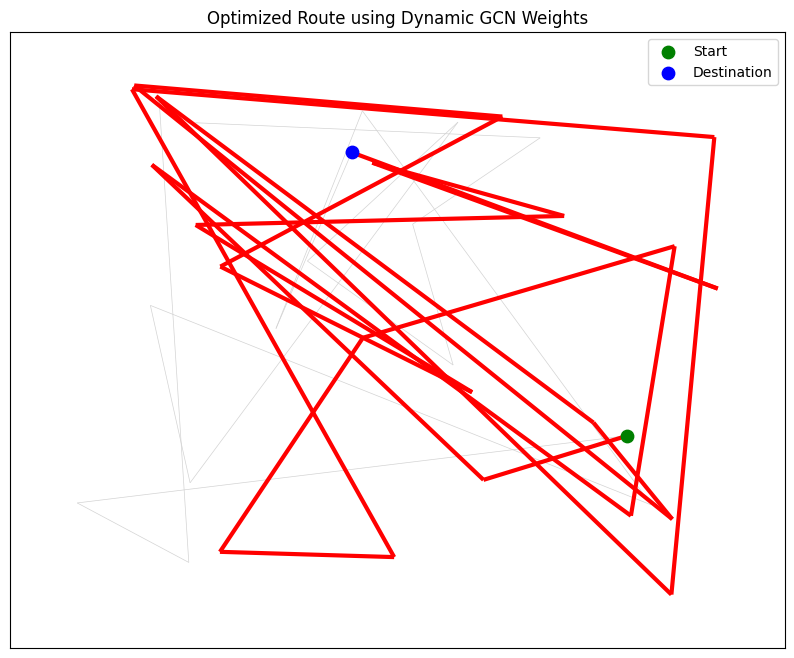

In [77]:
# Route Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Draw graph
pos = {node: (node[1], node[0]) for node in G_connected.nodes()}

nx.draw_networkx_edges(
    G_connected,
    pos,
    edge_color="lightgray",
    width=0.5
)

# Draw Dijkstra path
path_edges = list(zip(dynamic_path[:-1], dynamic_path[1:]))

nx.draw_networkx_edges(
    G_connected,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=3
)

# Start node
nx.draw_networkx_nodes(
    G_connected,
    pos,
    nodelist=[start_node],
    node_color="green",
    node_size=80,
    label="Start"
)

# End node
nx.draw_networkx_nodes(
    G_connected,
    pos,
    nodelist=[end_node],
    node_color="blue",
    node_size=80,
    label="Destination"
)

plt.title("Optimized Route using Dynamic GCN Weights")
plt.legend()
plt.show()

In [78]:
# Route Improvement Summary
print("=" * 50)
print("Real-Time Smart Traffic Routing Results")
print("=" * 50)

print(f"Original Route Cost : {original_cost:.2f}")
print(f"Dynamic Route Cost  : {dynamic_cost:.2f}")
print(f"A* Route Cost       : {astar_cost:.2f}")

difference = dynamic_cost - original_cost
percentage = (difference / original_cost) * 100

print(f"Cost Difference     : {difference:.2f}")
print(f"Percentage Change   : {percentage:.2f}%")

Real-Time Smart Traffic Routing Results
Original Route Cost : 296.55
Dynamic Route Cost  : 416.27
A* Route Cost       : 416.27
Cost Difference     : 119.72
Percentage Change   : 40.37%


In [79]:
# Training Loss & Accuracy Graphs
train_losses = []
train_accs = []
test_accs = []

for epoch in range(50):

    loss = train()

    train_accuracy = evaluate(data_sample.train_mask)
    test_accuracy = evaluate(data_sample.test_mask)

    train_losses.append(loss)
    train_accs.append(train_accuracy)
    test_accs.append(test_accuracy)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss:.4f} | "
        f"Train={train_accuracy:.4f} | "
        f"Test={test_accuracy:.4f}"
    )

Epoch 01 | Loss=0.9033 | Train=0.5754 | Test=0.5770
Epoch 02 | Loss=0.9031 | Train=0.5777 | Test=0.5798
Epoch 03 | Loss=0.8988 | Train=0.5804 | Test=0.5839
Epoch 04 | Loss=0.8937 | Train=0.5817 | Test=0.5842
Epoch 05 | Loss=0.8914 | Train=0.5832 | Test=0.5848
Epoch 06 | Loss=0.8907 | Train=0.5838 | Test=0.5857
Epoch 07 | Loss=0.8891 | Train=0.5842 | Test=0.5863
Epoch 08 | Loss=0.8864 | Train=0.5832 | Test=0.5853
Epoch 09 | Loss=0.8846 | Train=0.5831 | Test=0.5835
Epoch 10 | Loss=0.8844 | Train=0.5830 | Test=0.5816
Epoch 11 | Loss=0.8842 | Train=0.5836 | Test=0.5821
Epoch 12 | Loss=0.8821 | Train=0.5846 | Test=0.5844
Epoch 13 | Loss=0.8797 | Train=0.5844 | Test=0.5877
Epoch 14 | Loss=0.8789 | Train=0.5847 | Test=0.5889
Epoch 15 | Loss=0.8792 | Train=0.5850 | Test=0.5887
Epoch 16 | Loss=0.8788 | Train=0.5851 | Test=0.5898
Epoch 17 | Loss=0.8773 | Train=0.5853 | Test=0.5884
Epoch 18 | Loss=0.8760 | Train=0.5864 | Test=0.5881
Epoch 19 | Loss=0.8756 | Train=0.5877 | Test=0.5881
Epoch 20 | L

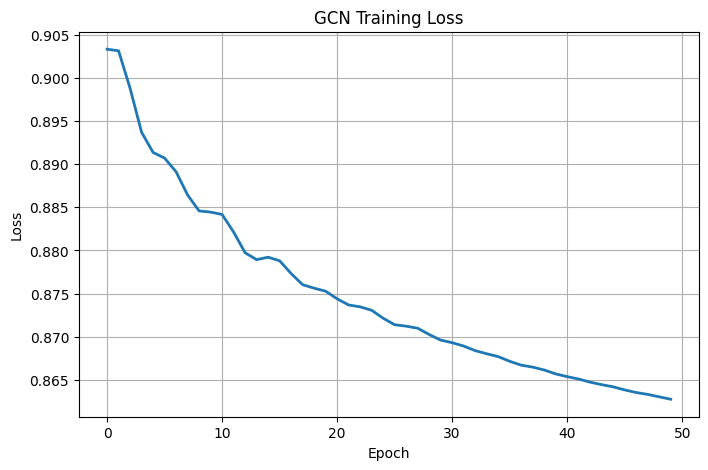

In [80]:
# Loss Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, linewidth=2)

plt.title("GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

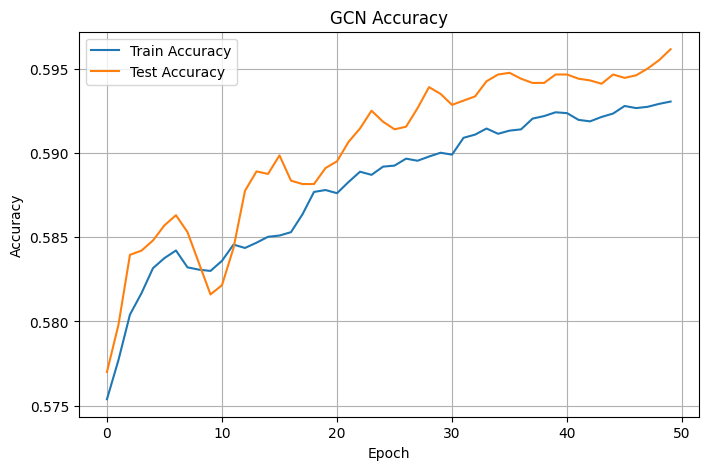

In [81]:
# Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("GCN Accuracy")

plt.legend()

plt.grid(True)

plt.show()

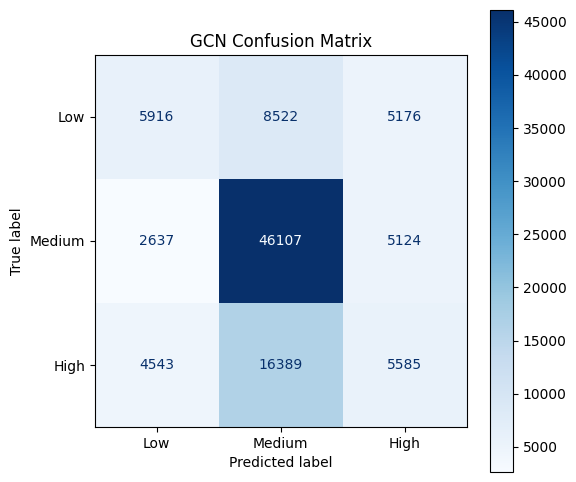

In [82]:
# Confusion Matrix Heatmap
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Low",
        "Medium",
        "High"
    ]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True
)

plt.title("GCN Confusion Matrix")

plt.show()

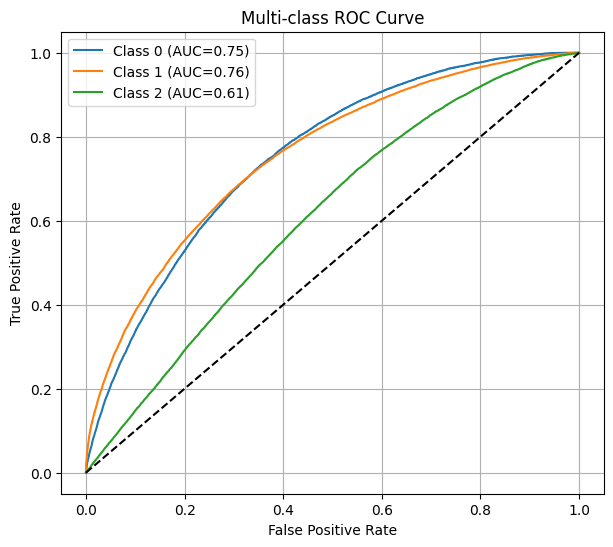

In [83]:
# ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

classes = [0,1,2]

y_true = label_binarize(
    data_sample.y.numpy(),
    classes=classes
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(
        y_true[:,i],
        probs[:,i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

plt.figure(figsize=(7,6))

for i in range(3):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC={roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Multi-class ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [84]:
# Interactive Folium Map
import folium

center = [
    sample_df["Latitude"].mean(),
    sample_df["Longitude"].mean()
]

m = folium.Map(
    location=center,
    zoom_start=13
)

for node in dynamic_path:

    folium.CircleMarker(
        location=[node[0], node[1]],
        radius=4,
        color="red",
        fill=True
    ).add_to(m)

m

In [85]:
# Real-Time Traffic Simulation
import time
import random

for i in range(10):

    edge = random.choice(list(G_connected.edges()))

    new_weight = random.uniform(1,10)

    G_connected[edge[0]][edge[1]]["dynamic_weight"] = new_weight

    print(
        f"Update {i+1}:",
        edge,
        "->",
        round(new_weight,2)
    )

    time.sleep(1)

Update 1: ((40.721668, -73.991942), (40.734933, -73.99493)) -> 3.16
Update 2: ((40.735709, -73.983742), (40.740728, -73.997908)) -> 8.59
Update 3: ((40.70307, -74.011459), (40.708674, -74.019695)) -> 5.8
Update 4: ((40.716237, -73.981574), (40.746981, -74.013873)) -> 5.73
Update 5: ((40.710573, -74.011364), (40.727284, -74.014296)) -> 3.0
Update 6: ((40.747648, -74.015654), (40.703573, -73.996294)) -> 7.56
Update 7: ((40.73094, -74.009126), (40.719105, -73.990537)) -> 4.59
Update 8: ((40.734858, -74.01095), (40.735709, -73.983742)) -> 1.4
Update 9: ((40.745072, -73.988304), (40.73094, -74.009126)) -> 2.57
Update 10: ((40.70307, -74.011459), (40.708674, -74.019695)) -> 2.02
